# Exercice 2 — Implémenter le Q-Learning avec une Q-table

## Objectif

Après avoir utilisé une bibliothèque dans l'exercice 1, cet exercice
implémente directement l'apprentissage par renforcement :

1. représenter `Q(état, action)` par une table NumPy ;
2. coder la stratégie epsilon-greedy et la mise à jour de Bellman ;
3. évaluer la politique sans exploration ;
4. visualiser une réussite et un échec.

**Fichiers produits :** `q_table_frozenlake.npy`,
`frozenlake_reussite.gif` et `frozenlake_echec.gif`.


## 1. Comprendre FrozenLake-v1

L'agent traverse une grille 4 × 4, du départ `S` au but `G`, en évitant les
trous `H`.

```
S F F F
F H F H
F F F H
H F F G
```

| Élément | Description |
|---|---|
| États | 16 cases numérotées de 0 à 15 |
| Actions | gauche, bas, droite, haut |
| Récompense | `1` au but, `0` ailleurs |
| Dynamique | glissante et stochastique (`is_slippery=True`) |

L'action demandée n'est suivie qu'une fois sur trois ; les autres transitions
partent latéralement. Même une bonne politique ne réussit donc pas à 100 %.


## 2. Comprendre le Q-Learning

### 2.1 La Q-table : la « qualité » de chaque choix

La **Q-table** est un tableau `16 lignes × 4 colonnes`. La case `Q[état, action]` estime la **récompense totale future** espérée si, depuis cet `état`, on joue cette `action` (puis qu'on continue de bien jouer). Au départ on ne sait rien → **toutes les cases valent 0**. L'entraînement va les remplir petit à petit.

Une fois la table apprise, **agir** devient trivial : dans un état, on prend l'action de **plus grande valeur Q** (`np.argmax`).

### 2.2 Explorer ou exploiter ? La stratégie *epsilon-greedy*

Dilemme central du RL : faut-il **exploiter** ce qu'on croit être le meilleur choix, ou **explorer** au hasard pour découvrir mieux ?

- avec probabilité **ε** (*epsilon*) → on **explore** (action aléatoire) ;
- avec probabilité **1 − ε** → on **exploite** (`np.argmax` de la Q-table).

Au début `ε = 1` (exploration totale), puis on le fait **décroître** : à mesure que l'agent apprend, il explore moins et exploite davantage.

### 2.3 La mise à jour de Bellman

Après chaque transition `(état, action) → (récompense, nouvel_état)`, on corrige la valeur Q :

$$Q[s, a] \;\leftarrow\; Q[s, a] \;+\; \alpha \,\Big( \; \underbrace{r + \gamma \max_{a'} Q[s', a']}_{\text{cible}} \;-\; \underbrace{Q[s, a]}_{\text{prédiction actuelle}} \Big)$$

En Python :
```python
q_table[state, action] += lr * (reward + gamma * np.max(q_table[new_state]) - q_table[state, action])
```

- **`lr` (α, *learning rate*)** : ampleur de la correction à chaque pas (0 = on n'apprend pas ; 1 = on remplace tout).
- **`gamma` (γ, *discount factor*)** : importance des récompenses **futures** vs immédiates (proche de 1 = vision long terme).
- **`r + γ·max Q[s']`** : la **cible** — la récompense reçue *plus* la meilleure valeur atteignable depuis le nouvel état.
- **le terme entre parenthèses** est l'**erreur de prédiction** (*TD error*) : l'écart entre la prédiction et la cible ; on pousse `Q` dans cette direction.


## 3. Initialiser la Q-table


In [1]:
import gymnasium as gym
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)

env = gym.make("FrozenLake-v1", is_slippery=True)
env.reset(seed=SEED)
env.action_space.seed(SEED)

n_etats = env.observation_space.n
n_actions = env.action_space.n
q_table = np.zeros((n_etats, n_actions))

print(f"Nombre d'états   : {n_etats}")
print(f"Nombre d'actions : {n_actions}")
print(f"Forme de la Q-table : {q_table.shape}")
print(q_table)


Nombre d'états   : 16
Nombre d'actions : 4
Forme de la Q-table : (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### 3.1 Choisir les hyperparamètres

Le lac est stochastique : un faible taux d'apprentissage évite de sur-réagir à
une transition isolée. `gamma` reste proche de 1 car la seule récompense utile
arrive à la fin du chemin. L'exploration décroît progressivement, sans devenir
nulle pendant l'entraînement.


In [2]:
n_episodes_entrainement = 20_000
max_pas_par_episode = 100

learning_rate = 0.1
discount_factor = 0.99

max_epsilon = 1.0
min_epsilon = 0.05
decay_rate = 0.0005


## 4. Entraîner la Q-table

À chaque pas, l'agent explore ou exploite, observe la transition puis rapproche
`Q[s, a]` de la cible de Bellman. La valeur future est annulée lorsque
l'épisode est terminé.

La récompense d'entraînement inclut encore 5 % d'exploration à la fin ; elle ne
doit donc pas être confondue avec l'évaluation déterministe qui suivra.


In [3]:
q_table = np.zeros((n_etats, n_actions))
epsilon = max_epsilon
rng = np.random.default_rng(SEED)
recompenses_par_episode = []

for episode in range(n_episodes_entrainement):
    state, _ = env.reset(seed=SEED + episode)
    terminated = truncated = False
    recompense_episode = 0.0

    for _ in range(max_pas_par_episode):
        if rng.random() < epsilon:
            action = int(rng.integers(n_actions))
        else:
            action = int(np.argmax(q_table[state]))

        new_state, reward, terminated, truncated, _ = env.step(action)
        fini = terminated or truncated
        valeur_future = 0.0 if fini else np.max(q_table[new_state])
        cible = reward + discount_factor * valeur_future
        q_table[state, action] += learning_rate * (
            cible - q_table[state, action]
        )

        state = new_state
        recompense_episode += reward
        if fini:
            break

    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(
        -decay_rate * (episode + 1)
    )
    recompenses_par_episode.append(recompense_episode)

print("Entraînement terminé.")
print(
    "Réussite sur les 1 000 derniers épisodes, exploration comprise : "
    f"{np.mean(recompenses_par_episode[-1000:]):.1%}"
)
print(f"Epsilon final : {epsilon:.3f}")


Entraînement terminé.
Réussite sur les 1 000 derniers épisodes, exploration comprise : 51.3%
Epsilon final : 0.050


### 4.1 Visualiser l'apprentissage


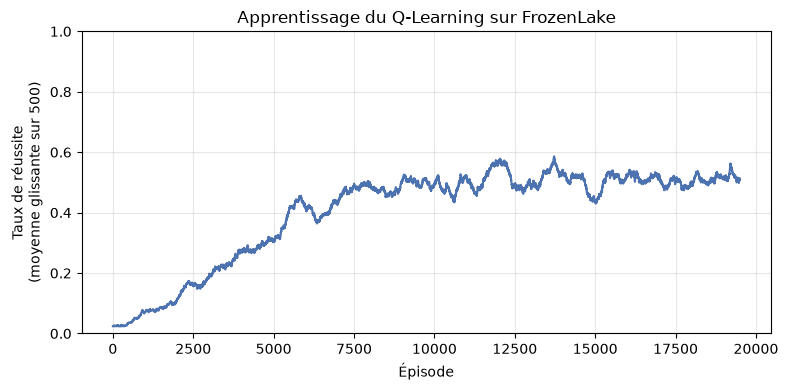

In [4]:
import matplotlib.pyplot as plt

recompenses = np.array(recompenses_par_episode)
fenetre = 500
# moyenne glissante = taux de réussite lissé sur `fenetre` épisodes
taux_glissant = np.convolve(recompenses, np.ones(fenetre) / fenetre, mode="valid")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(taux_glissant, color="#4C72B0")
ax.set_xlabel("Épisode")
ax.set_ylabel(f"Taux de réussite\n(moyenne glissante sur {fenetre})")
ax.set_title("Apprentissage du Q-Learning sur FrozenLake")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Évaluer la politique

L'évaluation utilise uniquement `argmax(Q[s])`, sur 1 000 seeds réservées.
Chaque épisode reçoit ainsi une condition initiale reproductible et aucune
action exploratoire n'est ajoutée.


In [5]:
n_episodes_eval = 1_000
eval_seed_start = 10_000
victoires = 0

for episode in range(n_episodes_eval):
    state, _ = env.reset(seed=eval_seed_start + episode)
    terminated = truncated = False

    for _ in range(max_pas_par_episode):
        action = int(np.argmax(q_table[state]))
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            victoires += int(reward == 1.0)
            break

taux_reussite = victoires / n_episodes_eval
np.save("q_table_frozenlake.npy", q_table)
print(f"Taux de réussite sur {n_episodes_eval} épisodes : {taux_reussite:.1%}")
print("Q-table sauvegardée : q_table_frozenlake.npy")


Taux de réussite sur 1000 épisodes : 72.9%
Q-table sauvegardée : q_table_frozenlake.npy


### 5.1 Lire la Q-table

La heatmap montre les quatre valeurs Q de chaque état. La politique associée
retient simplement la colonne maximale de chaque ligne, affichée ensuite comme
une flèche sur la grille.


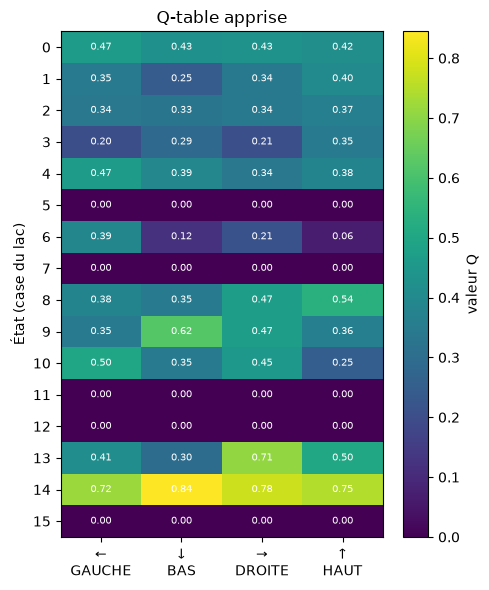

Politique apprise (meilleure action par case) :

 ← | ↑ | ↑ | ↑ 
 ← | H | ← | H 
 ↑ | ↓ | ← | H 
 H | → | ↓ | G 


In [6]:
import matplotlib.pyplot as plt

# --- (a) Heatmap de la Q-table ---
fig, ax = plt.subplots(figsize=(5, 6))
im = ax.imshow(q_table, cmap="viridis", aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["←\nGAUCHE", "↓\nBAS", "→\nDROITE", "↑\nHAUT"])
ax.set_yticks(range(16))
ax.set_ylabel("État (case du lac)")
ax.set_title("Q-table apprise")
for i in range(16):
    for j in range(4):
        ax.text(j, i, f"{q_table[i, j]:.2f}", ha="center", va="center",
                color="white", fontsize=7)
fig.colorbar(im, ax=ax, label="valeur Q")
plt.tight_layout()
plt.show()

# --- (b) Politique déduite, affichée sur la grille 4x4 ---
fleches = ["←", "↓", "→", "↑"]
desc = env.unwrapped.desc          # carte en octets : b'S', b'F', b'H', b'G'
print("Politique apprise (meilleure action par case) :\n")
for ligne in range(4):
    cases = []
    for col in range(4):
        etat = ligne * 4 + col
        lettre = desc[ligne, col]
        if lettre == b"H":
            cases.append(" H ")                                  # trou
        elif lettre == b"G":
            cases.append(" G ")                                  # but
        else:
            cases.append(f" {fleches[np.argmax(q_table[etat])]} ")
    print("|".join(cases))

## 6. Visualiser une réussite et un échec

L'environnement est recréé avec `render_mode="rgb_array"`. La recherche parcourt
des seeds contrôlées jusqu'à trouver un épisode gagné et un épisode perdu, puis
enregistre les images en GIF.

La limite interne et la boucle utilisent toutes deux 100 pas. `terminated`
correspond au but ou à un trou ; `truncated` à la limite de temps.


Réussite — 73 pas


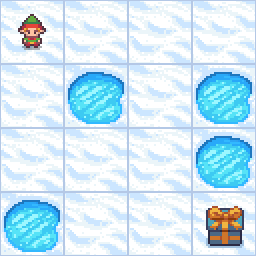

Échec — 100 pas


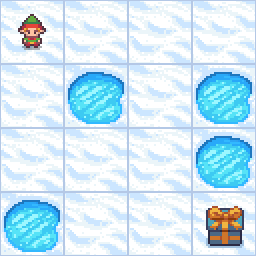

In [7]:
import os

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

import imageio.v2 as imageio
from IPython.display import Image, display

env_viz = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
    render_mode="rgb_array",
    max_episode_steps=max_pas_par_episode,
)


def jouer_un_episode(seed):
    """Joue la politique apprise et renvoie ses images et son issue."""
    state, _ = env_viz.reset(seed=seed)
    images = [env_viz.render()]
    terminated = truncated = False
    reward = 0.0

    while not (terminated or truncated):
        action = int(np.argmax(q_table[state]))
        state, reward, terminated, truncated, _ = env_viz.step(action)
        images.append(env_viz.render())

    return images, reward == 1.0


frames_reussite = frames_echec = None
for essai in range(500):
    images, a_gagne = jouer_un_episode(seed=20_000 + essai)
    if a_gagne and frames_reussite is None:
        frames_reussite = images
    if not a_gagne and frames_echec is None:
        frames_echec = images
    if frames_reussite is not None and frames_echec is not None:
        break
env_viz.close()


def sauver_et_afficher(images, chemin, titre):
    if images is None:
        print(f"{titre} : aucun exemple trouvé.")
        return
    imageio.mimsave(chemin, images, fps=3)
    print(f"{titre} — {len(images) - 1} pas")
    display(Image(filename=chemin))


sauver_et_afficher(
    frames_reussite, "frozenlake_reussite.gif", "Réussite"
)
sauver_et_afficher(frames_echec, "frozenlake_echec.gif", "Échec")


## 7. Bilan et limites

La Q-table rend la politique directement inspectable et obtient un taux de
réussite nettement supérieur au hasard, sans atteindre 100 % à cause de la
glisse.

Cette méthode convient aux petits espaces discrets. Elle ne passe pas à
l'échelle pour CartPole, dont les observations sont continues : l'exercice 3
remplacera donc la table par un réseau de neurones.